# **Mineral Prospectivity Project**
## 02b National Geochemical Database (NGDB) exploratory data analysis

goals:\
-create plots and maps to investigate distributions, correlations and spatial trends

### Part 1. import packages and identify local directory
a. import packages needed for data loading and analysis

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import glob
import os

data_path = "/Users/adbyerly/prospectivity_model/data/processed/"

### Part 2. load processed data

In [ ]:
# csv - load all geochemical files from the processed folder into a dictionary
files = glob.glob(data_path + "NGDB/*.csv")
ngdb_dfs_processed={}

for file in files:
    name = os.path.basename(file).replace(".csv", "")
    df = pd.read_csv(file, low_memory=False)
    ngdb_dfs_processed[name] = df

ngdb_dfs_processed.keys()

In [ ]:
# examine processed dataframes

for name, df in ngdb_dfs_processed.items():
    print(name)
    print(df.head())
    print(df.columns)
    print(df.shape)
    print("-" * 25)

### Part 3. investigate data and document observations

a. start with the "Rock Data" dataframe which contains information about the samples

In [ ]:
# set variable for this table
rockdata = ngdb_dfs_processed['Rock_Data']

print(rockdata.head())
print(rockdata.columns)
print(rockdata.dtypes)

In [ ]:
# general observations about sample quantity and locations

print ('There are ' + str(len(rockdata)) + ' samples.')

# print(rockdata['depth'].nunique())
# print(rockdata['depth'].unique())

# observation --------
print('All samples are effectively from the surface.')

print('Samples come from ' + str(rockdata['locat_desc'].nunique()) + ' locations.')

<StringArray>
['rock']
Length: 1, dtype: str
<StringArray>
['metamorphic', nan, 'sedimentary', 'igneous', 'unidentified']
Length: 5, dtype: str
xndryclass
igneous         13095
metamorphic      6249
sedimentary      4527
NaN              2392
unidentified      258
Name: count, dtype: int64


<Axes: xlabel='xndryclass'>

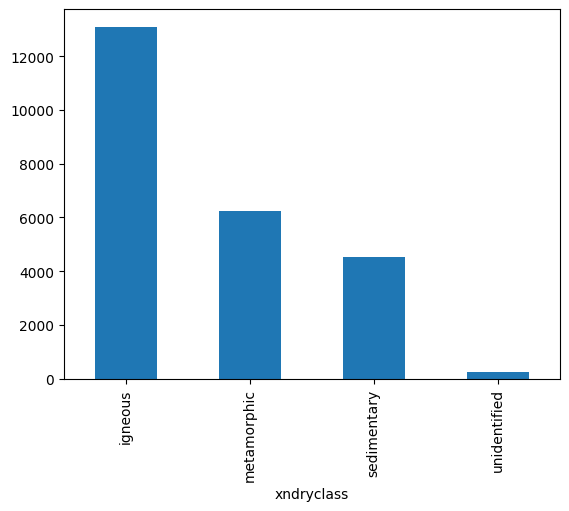

In [94]:
# identify types of rocks



# -------- these don't contain apparently useful information
# print(rockdata['source_rk'].nunique())
# print(rockdata['source_rk'].unique())
# print(rockdata['source_rk'].value_counts(dropna=False))

# print(rockdata['sample_src'].nunique())
# print(rockdata['sample_src'].unique())

# print(rockdata['metamrphsm'].nunique())
# print(rockdata['metamrphsm'].unique())
# -------- these don't contain apparently useful information



# 'xnddryclass' feature contains information about the rock type
print(rockdata['primeclass'].unique())
print(rockdata['xndryclass'].unique())
print(rockdata['xndryclass'].value_counts(dropna=False))

rockdata['xndryclass'].value_counts().plot(kind='bar')

In [ ]:
# examine ages of igneous rocks

mask = rockdata['xndryclass'] == 'igneous'
igneous = rockdata[mask]

print(igneous['geol_age'].nunique())
print(igneous['geol_age'].unique().tolist())

In [ ]:
print(igneous['spec_name'].unique().tolist())
print(igneous.columns)

b. major element chemistry in igneous subset

In [100]:
# filter chemical analysis tables to igenous rocks

igneous_id = igneous['lab_id']
igneous_chem = {}

for d, df in ngdb_dfs_processed.items():
    igneous_chem[d] = df[df['lab_id'].isin(igneous_id)].copy()  # copy df, filter to igneous rock primary key values 


print(igneous_chem.keys())

dict_keys(['Rock_Data', 'XRF', 'Unknown_chem', 'Other_chem', 'ES', 'ICPAES', 'ICPMS', 'Major_element', 'NAA'])
(4463, 192)


In [ ]:
# examine direct gold concentration measurements
# from metadata, these are the geochemical data tables that contain direct gold measurements:

# - NAA
# - ICPAES
# - ICPMS
# - ES

['lab_id', 'capct_na', 'capct_naq', 'fepct_na', 'fepct_naq', 'fe_cvpct', 'kpct_na', 'kpct_naq', 'k_cvpct', 'napct_na', 'napct_naq', 'na_cvpct', 'asppm_na', 'asppm_naq', 'as_cvpct', 'auppb_na', 'auppb_naq', 'au_cvpct', 'bappm_na', 'bappm_naq', 'ba_cvpct', 'brppm_na', 'brppm_naq', 'cdppm_na', 'cdppm_naq', 'cd_cvpct', 'ceppm_na', 'ceppm_naq', 'ce_cvpct', 'coppm_na', 'coppm_naq', 'co_cvpct', 'crppm_na', 'crppm_naq', 'cr_cvpct', 'csppm_na', 'csppm_naq', 'cs_cvpct', 'cuppm_na', 'cuppm_naq', 'cu_cvpct', 'dyppm_na', 'dyppm_naq', 'dy_cvpct', 'euppm_na', 'euppm_naq', 'eu_cvpct', 'gappm_na', 'gappm_naq', 'gdppm_na', 'gdppm_naq', 'gd_cvpct', 'hfppm_na', 'hfppm_naq', 'hf_cvpct', 'hgppm_na', 'hgppm_naq', 'hg_cvpct', 'hoppm_na', 'hoppm_naq', 'ho_cvpct', 'irppb_na', 'irppb_naq', 'ir_cvpct', 'lappm_na', 'lappm_naq', 'la_cvpct', 'luppm_na', 'luppm_naq', 'lu_cvpct', 'mnppm_na', 'mnppm_naq', 'mn_cvpct', 'moppm_na', 'moppm_naq', 'ndppm_na', 'ndppm_naq', 'nd_cvpct', 'nippm_na', 'nippm_naq', 'ni_cvpct', 'rbp

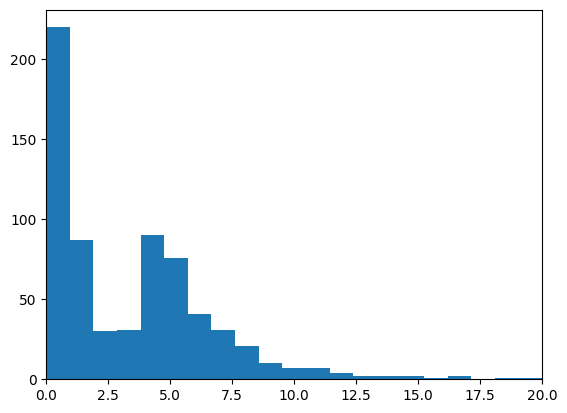

In [140]:
# NAA

NAA = igneous_chem['NAA']
print(NAA.columns.tolist())
print(NAA.columns[NAA.columns.str.contains('au')])
NAA_gold = NAA['auppb_na']

print(NAA_gold.describe())
plt.hist(NAA_gold, range = (0,20), bins='auto')
plt.xlim(0, 20)
plt.show()